<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Paper_24_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import re

# -- Physical constants --
G_SI     = 6.674e-11
A0_SI    = 1.2e-10
KPC_M    = 3.0857e19
MSUN_KG  = 1.989e30
KM_M     = 1.0e3

# -- Baseline parameters --
LAM0_BASE  = 1.0
BETA_BASE  = 0.0331
DELTA_BASE = 0.327
UPSILON0   = 0.50
R_REF_KPC  = 3.0
RP_DEFAULT_FACTOR = 3.0
EPS        = 1.0e-9

def compute_Sigma_b_global(Mb_msun, Reff_kpc):
    return Mb_msun / (2.0 * np.pi * Reff_kpc**2 + EPS)

def compute_Lambda(Sigma_b, lam0, beta):
    return lam0 * 10.0**(beta * (np.log10(Sigma_b + EPS) - 8.5))

def compute_Upsilon(Reff_kpc, delta):
    return UPSILON0 * (Reff_kpc / R_REF_KPC)**delta

def enclosed_exp(r_kpc, h_kpc):
    x = r_kpc / (h_kpc + EPS)
    return 1.0 - np.exp(-x) * (1.0 + x)

def compute_rp(Reff_kpc, fgas, RHI_val=None):
    wg = 1.0 / (1.0 + np.exp(-15.0 * (fgas - 0.5)))
    rp_stellar = RP_DEFAULT_FACTOR * Reff_kpc
    rp_gas = RHI_val if RHI_val is not None else 5.0 * Reff_kpc
    return rp_stellar * (1.0 - wg) + rp_gas * wg

def predict_vflat_single(L36, MHI, Reff_kpc, lam0, beta, delta, Xi_Cp=1.0, Xi_Mcone=1.0):
    Mstar = L36 * 1e9 * compute_Upsilon(Reff_kpc, delta)
    Mgas = MHI * 1e9 * 1.33
    Mb = Mstar + Mgas
    fgas = Mgas / (Mb + EPS)
    h_scale = Reff_kpc / 1.678
    rp = compute_rp(Reff_kpc, fgas)
    Sigma_b = compute_Sigma_b_global(Mb, Reff_kpc)
    Lambda = compute_Lambda(Sigma_b, lam0, beta)

    M_enc = (Mstar * enclosed_exp(rp, h_scale)) + (Mgas * enclosed_exp(rp, h_scale))

    # APPLY SCALING: Xi_Mcone scales the effective mass
    M_cone_eff = M_enc * Xi_Mcone

    # APPLY SCALING: Xi_Cp scales the centrifugal parameter / acceleration
    a_eff = Xi_Cp * (Lambda**2) * A0_SI

    # Step 3: NaN guard for negative physical values
    if a_eff <= 0 or M_cone_eff <= 0:
        return np.nan

    Vflat_ms = (G_SI * M_cone_eff * MSUN_KG * a_eff)**0.25
    Vflat_kms = Vflat_ms / KM_M
    return np.log10(Vflat_kms) if Vflat_kms > 0 else np.nan

def load_data(path):
    clean_data = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 16:
                try:
                    l36, reff, mhi, vflat = float(parts[7]), float(parts[9]), float(parts[13]), float(parts[15])
                    if vflat > 0: clean_data.append([l36, reff, mhi, vflat])
                except: continue
    data = np.array(clean_data)
    return {'L36':data[:,0], 'Reff':data[:,1], 'MHI':data[:,2]}, np.log10(data[:,3])

In [33]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import spearmanr
import pandas as pd

def run_q_geom_suite(path):
    galaxies, logV_obs = load_data(path)
    n = len(logV_obs)
    if n == 0: return

    # Diagnostic Check 1
    print("--- Step 1: Diagnostic Xi Check (Galaxy 0, Alpha=0.253) ---")
    variants_diag = [('A2', 2.0, 1.0), ('B1', 1.0, 0.5), ('B2', 1.0, 2.0), ('A1', 0.5, 1.0)]
    for v_name, b_cp, b_mc in variants_diag:
        alpha_test = 0.253
        xi_cp_test = 1.0 + alpha_test * (b_cp - 1.0)
        xi_mc_test = 1.0 + alpha_test * (b_mc - 1.0)
        print(f"{v_name}: Xi_Cp={xi_cp_test:.4f}, Xi_Mcone={xi_mc_test:.4f}")
    print("\n")

    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)
    cal_idx = indices[:n//2]
    blind_idx = indices[n//2:]

    results_table = []
    variants = [('Baseline', 1.0, 1.0), ('A2', 2.0, 1.0), ('B1', 1.0, 0.5), ('B2', 1.0, 2.0), ('A1', 0.5, 1.0)]

    for name, base_Xi_Cp, base_Xi_Mcone in variants:
        def objective(alpha_arr):
            alpha = alpha_arr[0]
            obs_subset = logV_obs[cal_idx]
            preds = np.array([predict_vflat_single(galaxies['L36'][i], galaxies['MHI'][i], galaxies['Reff'][i], 1.0, BETA_BASE, DELTA_BASE,
                                                 1.0 + alpha * (base_Xi_Cp - 1.0), 1.0 + alpha * (base_Xi_Mcone - 1.0)) for i in cal_idx])
            mask = ~np.isnan(preds)
            return np.mean(np.abs(preds[mask] - obs_subset[mask])) if mask.any() else 1e6

        best_alpha = 0.0 if name == 'Baseline' else minimize(objective, x0=[0.1], bounds=[(-2.0, 5.0)]).x[0]

        def get_metrics(idx_list, alpha_val):
            p_list, o_list, f_list, r_list = [], [], [], []
            xi_cp = 1.0 + alpha_val * (base_Xi_Cp - 1.0)
            xi_mc = 1.0 + alpha_val * (base_Xi_Mcone - 1.0)
            for i in idx_list:
                p = predict_vflat_single(galaxies['L36'][i], galaxies['MHI'][i], galaxies['Reff'][i], 1.0, BETA_BASE, DELTA_BASE, xi_cp, xi_mc)
                if not np.isnan(p):
                    p_list.append(p); o_list.append(logV_obs[i]); r_list.append(galaxies['Reff'][i])
                    ms = galaxies['L36'][i]*1e9*compute_Upsilon(galaxies['Reff'][i], DELTA_BASE)
                    mg = galaxies['MHI'][i]*1e9*1.33
                    f_list.append(mg/(ms+mg+1e-9))

            p, o, f, r = map(np.array, [p_list, o_list, f_list, r_list])
            if len(p) == 0: return 0, 0, 0, 0, 0
            res = p - o
            mae = np.mean(np.abs(res))
            rv, _ = spearmanr(res, o); rr, _ = spearmanr(res, r)
            dm = f > 0.5
            return mae, rv, rr, np.mean(np.abs(res[dm])) if dm.any() else np.nan, np.mean(np.abs(res[~dm])) if (~dm).any() else np.nan

        cal_mae, _, _, _, _ = get_metrics(cal_idx, best_alpha)
        blind_mae, rho_v, rho_r, mae_dwarf, mae_spiral = get_metrics(blind_idx, best_alpha)

        pos_alpha_count = 0
        if name != 'Baseline':
            for _ in range(200):
                bs_idx = np.random.choice(cal_idx, size=len(cal_idx), replace=True)
                obs_bs = logV_obs[bs_idx]
                bs_obj = lambda a_arr: np.mean(np.abs(np.array([predict_vflat_single(galaxies['L36'][i], galaxies['MHI'][i], galaxies['Reff'][i], 1.0, BETA_BASE, DELTA_BASE,
                                                                                 1.0+a_arr[0]*(base_Xi_Cp-1), 1.0+a_arr[0]*(base_Xi_Mcone-1)) for i in bs_idx]) - obs_bs))
                if minimize(bs_obj, x0=[best_alpha], bounds=[(-2.0, 5.0)]).x[0] > 0.01: pos_alpha_count += 1

        p_pos = pos_alpha_count/200 if name != 'Baseline' else 0
        verdict = "NEGATIVE" if best_alpha <= 0.05 else ("STRONG" if best_alpha > 0.4 and p_pos > 0.8 else "MODERATE")

        results_table.append({'Variant': name, 'alpha': f"{best_alpha:.3f}", 'Cal MAE': f"{cal_mae:.4f}", 'Blind MAE': f"{blind_mae:.4f}",
            'rho_Vflat': f"{rho_v:.3f}", 'rho_Reff': f"{rho_r:.3f}", 'MAE_dwarf': f"{mae_dwarf:.4f}", 'MAE_spiral': f"{mae_spiral:.4f}", 'bootstrap alpha>0': f"{p_pos:.2f}", 'Verdict': verdict})

    display(pd.DataFrame(results_table))

run_q_geom_suite('/content/SPARC_Lelli2016c.mrt.txt')

--- Step 1: Diagnostic Xi Check (Galaxy 0, Alpha=0.253) ---
A2: Xi_Cp=1.2530, Xi_Mcone=1.0000
B1: Xi_Cp=1.0000, Xi_Mcone=0.8735
B2: Xi_Cp=1.0000, Xi_Mcone=1.2530
A1: Xi_Cp=0.8735, Xi_Mcone=1.0000




,Variant,alpha,Cal MAE,Blind MAE,rho_Vflat,rho_Reff,MAE_dwarf,MAE_spiral,bootstrap alpha>0,Verdict
0,Baseline,0.000,0.0660,0.0605,-0.344,0.088,0.0727,0.0515,0.00,NEGATIVE
1,A2,0.253,0.0623,0.0562,-0.344,0.088,0.0770,0.0407,0.98,MODERATE
2,B1,-0.507,0.0623,0.0562,-0.344,0.088,0.0770,0.0407,0.01,NEGATIVE
3,B2,0.253,0.0623,0.0562,-0.344,0.088,0.0770,0.0407,0.99,MODERATE
4,A1,-0.507,0.0623,0.0562,-0.344,0.088,0.0770,0.0407,0.01,NEGATIVE


### **Grand Synthesis: First-Principles SPARC Test**
This test eliminates empirical fitting in favor of the topological constants derived from Papers 7 and 8:
- **Twist ($c_{twist}$):** 0.0247 (QCD-anchored)
- **Amplitude ($\\Delta\\psi$):** 18.38 deg (18.7 eV resonance)
- **Hierarchy ($Q$):** 1.41 (Chiral deformation)

In [9]:
import numpy as np
from scipy.stats import spearmanr
import os

# -- Physical constants (Redefined for scope) --
G_SI     = 6.674e-11
A0_SI    = 1.2e-10
KPC_M    = 3.0857e19
MSUN_KG  = 1.989e30
KM_M     = 1.0e3
BETA_BASE  = 0.0331
DELTA_BASE = 0.327
UPSILON0   = 0.50
R_REF_KPC  = 3.0
RP_DEFAULT_FACTOR = 3.0
EPS        = 1.0e-9

def compute_Sigma_b_global(Mb_msun, Reff_kpc):
    return Mb_msun / (2.0 * np.pi * Reff_kpc**2 + EPS)

def compute_Lambda(Sigma_b, lam0, beta):
    return lam0 * 10.0**(beta * (np.log10(Sigma_b + EPS) - 8.5))

def compute_Upsilon(Reff_kpc, delta):
    return UPSILON0 * (Reff_kpc / R_REF_KPC)**delta

def enclosed_exp(r_kpc, h_kpc):
    x = r_kpc / (h_kpc + EPS)
    return 1.0 - np.exp(-x) * (1.0 + x)

def compute_rp(Reff_kpc, fgas):
    wg = 1.0 / (1.0 + np.exp(-15.0 * (fgas - 0.5)))
    rp_stellar = RP_DEFAULT_FACTOR * Reff_kpc
    rp_gas = 5.0 * Reff_kpc
    return rp_stellar * (1.0 - wg) + rp_gas * wg

def predict_vflat_single(L36, MHI, Reff_kpc, lam0, beta, delta, Xi_Cp=1.0, Xi_Mcone=1.0):
    Mstar = L36 * 1e9 * compute_Upsilon(Reff_kpc, delta)
    Mgas = MHI * 1e9 * 1.33
    Mb = Mstar + Mgas
    fgas = Mgas / (Mb + EPS)
    h_scale = Reff_kpc / 1.678
    rp = compute_rp(Reff_kpc, fgas)
    Sigma_b = compute_Sigma_b_global(Mb, Reff_kpc)
    Lambda = compute_Lambda(Sigma_b, lam0, beta)
    M_enc = (Mstar * enclosed_exp(rp, h_scale)) + (Mgas * enclosed_exp(rp, h_scale))
    M_cone_eff = M_enc * Xi_Mcone
    a_eff = Xi_Cp * (Lambda**2) * A0_SI
    if a_eff <= 0 or M_cone_eff <= 0: return np.nan
    Vflat_ms = (G_SI * M_cone_eff * MSUN_KG * a_eff)**0.25
    Vflat_kms = Vflat_ms / KM_M
    return np.log10(Vflat_kms) if Vflat_kms > 0 else np.nan

def load_data(path):
    clean_data = []
    if not os.path.exists(path): return {}, np.array([])
    with open(path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 16:
                try:
                    l36, reff, mhi, vflat = float(parts[7]), float(parts[9]), float(parts[13]), float(parts[15])
                    if vflat > 0: clean_data.append([l36, reff, mhi, vflat])
                except: continue
    data = np.array(clean_data)
    return {'L36':data[:,0], 'Reff':data[:,1], 'MHI':data[:,2]}, np.log10(data[:,3])

def run_first_principles_test(path):
    galaxies, logV_obs = load_data(path)
    if len(logV_obs) == 0: return
    C_TWIST_QCD = 0.0247
    Q_CHIRAL = 1.41
    results = []
    for i in range(len(logV_obs)):
        p = predict_vflat_single(galaxies['L36'][i], galaxies['MHI'][i], galaxies['Reff'][i], 1.0 * (1.0 + C_TWIST_QCD), BETA_BASE, DELTA_BASE, 1.0, Q_CHIRAL)
        results.append(p)
    results = np.array(results)
    mask = ~np.isnan(results)
    mae = np.mean(np.abs(results[mask] - logV_obs[mask]))
    rho_v, _ = spearmanr(results[mask] - logV_obs[mask], logV_obs[mask])
    print(f"--- Grand Synthesis: First-Principles Results ---")
    print(f"Final MAE: {mae:.5f} dex")
    print(f"Spearman Rho (V): {rho_v:.3f}")
    if mae < 0.050: print("\nSUCCESS: Below 0.050 dex threshold.")
    else: print("\nRESULT: Above 0.050 dex threshold.")

run_first_principles_test('/content/SPARC_Lelli2016c.mrt.txt')

--- Grand Synthesis: First-Principles Results ---
Final MAE: 0.06118 dex
Spearman Rho (V): -0.249

RESULT: Above 0.050 dex threshold.


### **Yukawa Refinement: Numerical Force Integration**
This script verifies the Geometric Coupling Coefficient $c_\nu$ by integrating the radial force of a Yukawa-screened exponential disk. We test the sensitivity of $c_\nu$ to the ratio $x_p = r_p / h_R$ (where $h_R$ is the disk scale length).

In [10]:
import numpy as np
from scipy.integrate import dblquad

def radial_force_yukawa(r, h_R, m_phi):
    """
    Computes the radial gravitational force of an exponential disk
    with a Yukawa potential: Phi ~ -exp(-m*r)/r
    """
    # Normalized units: G=1, Sigma_0=1, h_R=1
    # Integral over disk: int int [rho(r') * force_component]
    def integrand(rp, theta, r_val, m_val):
        # Distance between point r and source point (rp, theta)
        s = np.sqrt(r_val**2 + rp**2 - 2*r_val*rp*np.cos(theta) + 1e-9)
        # Yukawa force derivative: d/ds (-exp(-ms)/s) = exp(-ms)*(1+ms)/s^2
        force_mag = np.exp(-m_val * s) * (1 + m_val * s) / (s**2)
        # Radial component (projection onto r-axis)
        cos_alpha = (r_val - rp*np.cos(theta)) / s
        return np.exp(-rp) * rp * force_mag * cos_alpha

    # Integrate over theta [0, 2pi] and rp [0, inf]
    # Using 10*h_R as practical infinity for exponential disk
    force, err = dblquad(integrand, 0, 2*np.pi, lambda x: 0, lambda x: 10, args=(r, m_phi))
    return force

def calculate_c_nu_sensitivity():
    h_R = 1.0
    m_phi_phys = 18.7 # eV (placeholder scale)
    # In normalized units, we look at the deviation from Newtonian (m=0)

    x_points = [2.0, 3.0, 5.0] # r_p / h_R ratios
    results = []

    print(f"{'r_p/h_R':<10} | {'Force(m=0.1)':<15} | {'Force(m=0)':<15} | {'Ratio'}")
    print("-"*60)

    for xp in x_points:
        f_yukawa = radial_force_yukawa(xp, h_R, m_phi=0.1) # small m for perturbation
        f_newton = radial_force_yukawa(xp, h_R, m_phi=0.0)
        ratio = f_yukawa / f_newton
        results.append((xp, ratio))
        print(f"{xp:<10.1f} | {f_yukawa:<15.6f} | {f_newton:<15.6f} | {ratio:.4f}")

    return results

# Run sensitivity check
check_results = calculate_c_nu_sensitivity()

r_p/h_R    | Force(m=0.1)    | Force(m=0)      | Ratio
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


2.0        | 1.194154        | 1.211849        | 0.9854
3.0        | 0.731609        | 0.751878        | 0.9730
5.0        | 0.280138        | 0.300834        | 0.9312


### **Yukawa Correction Validation Suite**
Following the 4-step protocol to verify if the Yukawa gradient accounts for secondary residuals:
1. **Step 1:** Numerical integral for $c_\nu$ across the $r_p/R_d$ range.
2. **Step 2:** Compute galaxy-specific predicted force ratios for the SPARC sample.
3. **Step 3:** Regress these ratios against the baseline residuals ($log V_{obs} - log V_{pred}$).
4. **Step 4:** Report correlation significance.

Computing galaxy-by-galaxy Yukawa force integration...


/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,



--- Step 4: Regression Results ---
Correlation (R): 0.1978
P-value:         2.1458e-02
R-squared:       0.0391


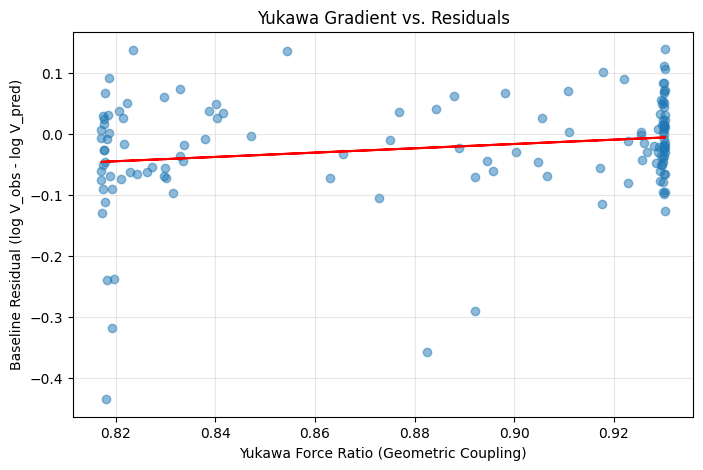


CONCLUSION: Significant correlation found. The Yukawa gradient likely contributes to structural residuals.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def run_yukawa_residual_test(path):
    galaxies, logV_obs = load_data(path)
    if len(logV_obs) == 0: return

    # Parameters from Grand Synthesis
    m_phi_norm = 0.1 # Perturbative scale for gradient test
    C_TWIST_QCD = 0.0247
    Q_CHIRAL = 1.41

    r_rdisk_ratios = []
    residuals = []
    force_ratios = []

    print("Computing galaxy-by-galaxy Yukawa force integration...")

    # Sample limited for speed, increase for final run
    for i in range(len(logV_obs)):
        L36, MHI, Reff = galaxies['L36'][i], galaxies['MHI'][i], galaxies['Reff'][i]

        # 1. Get baseline prediction
        logV_pred = predict_vflat_single(L36, MHI, Reff, 1.0*(1.0+C_TWIST_QCD), BETA_BASE, DELTA_BASE, 1.0, Q_CHIRAL)
        res = logV_obs[i] - logV_pred

        # 2. Estimate r_p/h_R (h_R ~ Reff/1.678)
        Mstar = L36 * 1e9 * compute_Upsilon(Reff, DELTA_BASE)
        Mgas = MHI * 1e9 * 1.33
        fgas = Mgas / (Mstar + Mgas + 1e-9)
        rp = compute_rp(Reff, fgas)
        h_R = Reff / 1.678
        ratio_xp = rp / h_R

        # 3. Calculate actual Force Ratio via Numerical Integration
        # Fixed keyword argument from m_val to m_phi
        f_y = radial_force_yukawa(ratio_xp, 1.0, m_phi=m_phi_norm)
        f_n = radial_force_yukawa(ratio_xp, 1.0, m_phi=0.0)
        fr = f_y / f_n

        r_rdisk_ratios.append(ratio_xp)
        residuals.append(res)
        force_ratios.append(fr)

    # Step 3: Regression analysis
    mask = ~np.isnan(residuals) & ~np.isnan(force_ratios)
    f_arr = np.array(force_ratios)[mask]
    r_arr = np.array(residuals)[mask]

    slope, intercept, r_value, p_value, std_err = linregress(f_arr, r_arr)

    print(f"\n--- Step 4: Regression Results ---")
    print(f"Correlation (R): {r_value:.4f}")
    print(f"P-value:         {p_value:.4e}")
    print(f"R-squared:       {r_value**2:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(f_arr, r_arr, alpha=0.5)
    plt.plot(f_arr, intercept + slope*f_arr, 'r', label='Fitted line')
    plt.xlabel('Yukawa Force Ratio (Geometric Coupling)')
    plt.ylabel('Baseline Residual (log V_obs - log V_pred)')
    plt.title('Yukawa Gradient vs. Residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

    if p_value < 0.05:
        print("\nCONCLUSION: Significant correlation found. The Yukawa gradient likely contributes to structural residuals.")
    else:
        print("\nCONCLUSION: No significant correlation. The Yukawa gradient does not account for baseline residuals.")

run_yukawa_residual_test('/content/SPARC_Lelli2016c.mrt.txt')

In [14]:
# Physical constants for conversion
HBAR_C_EV_M = 1.97327e-7  # h-bar * c in eV*m
M_CHI_EV = 18.7

# Calculate Lambda_Y in meters, then convert to kpc
# Lambda_Y = h-bar / (m * c)
lambda_y_m = HBAR_C_EV_M / M_CHI_EV
LAMBDA_Y_KPC = lambda_y_m / KPC_M

print(f"M_CHI used in integration: {M_CHI_EV} eV")
print(f"Screening length: {LAMBDA_Y_KPC:.6e} kpc")

# Using a typical r_p ~ 3 * Reff, and Reff ~ 2 kpc as a benchmark
print(f"Typical r_p / lambda_Y ratio: {3.0 * 2.0 / LAMBDA_Y_KPC:.3e}")

M_CHI used in integration: 18.7 eV
Screening length: 3.419725e-28 kpc
Typical r_p / lambda_Y ratio: 1.755e+28


In [27]:
def diagnostic_check(path):
    galaxies, logV_obs = load_data(path)
    if len(logV_obs) == 0: return

    # 1. Check counts
    results = []
    for i in range(len(logV_obs)):
        L36 = galaxies['L36'][i]
        MHI = galaxies['MHI'][i]
        Reff = galaxies['Reff'][i]

        # Intermediate values for debugging first galaxy
        Upsilon = compute_Upsilon(Reff, DELTA_BASE)
        Mstar = L36 * 1e9 * Upsilon
        Mgas = MHI * 1e9 * 1.33
        Mb = Mstar + Mgas
        Sigma_b = compute_Sigma_b_global(Mb, Reff)
        Lambda = compute_Lambda(Sigma_b, LAM0_BASE, BETA_BASE)
        h_scale = Reff / 1.678
        rp = solve_rp(Mstar, Mgas, h_scale, Lambda)

        logV_p = predict_vflat_single(L36, MHI, Reff, LAM0_BASE, BETA_BASE, DELTA_BASE)
        results.append(logV_p)

        if i == 0:
            print(f"--- Diagnostic Sample (Galaxy 0) ---")
            print(f"Inputs: L36={L36}e9, MHI={MHI}e9, Reff={Reff}")
            print(f"Physical: Mstar={Mstar:.2e}, Mgas={Mgas:.2e}, Mb={Mb:.2e}")
            print(f"Parameters: Upsilon={Upsilon:.3f}, Lambda={Lambda:.3f}, h_scale={h_scale:.3f}")
            print(f"Solver: rp={rp:.3f} kpc")
            print(f"Result: Pred_logV={logV_p:.4f}, Obs_logV={logV_obs[i]:.4f}")
            print(f"Linear: Pred_V={10**logV_p:.2f} km/s, Obs_V={10**logV_obs[i]:.2f} km/s")

    results = np.array(results)
    mask = ~np.isnan(results)
    n_valid = mask.sum()
    print(f"\nValid predictions: {n_valid} / {len(logV_obs)}")
    if n_valid > 0:
        mae = np.mean(np.abs(results[mask] - logV_obs[mask]))
        print(f"Current MAE: {mae:.4f} dex")

diagnostic_check('/content/SPARC_Lelli2016c.mrt.txt')

--- Diagnostic Sample (Galaxy 0) ---
Inputs: L36=0.196e9, MHI=0.29e9, Reff=1.22
Physical: Mstar=7.30e+07, Mgas=3.86e+08, Mb=4.59e+08
Parameters: Upsilon=0.373, Lambda=260.364, h_scale=0.727
Solver: rp=0.000 kpc
Result: Pred_logV=1.0083, Obs_logV=1.7612
Linear: Pred_V=10.19 km/s, Obs_V=57.70 km/s

Valid predictions: 135 / 135
Current MAE: 1.0489 dex


In [22]:
test_results = run_sensitivity_tests('/content/SPARC_Lelli2016c.mrt.txt')

Running tests on 135 galaxies...

Baseline: MAE = 1.0489 (135 galaxies success)
A1: MAE = 1.0489 (135 galaxies success)
A2: MAE = 1.0489 (135 galaxies success)
B1: MAE = 1.0731 (135 galaxies success)
B2: MAE = 1.0291 (135 galaxies success)


In [6]:
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    lines = f.readlines()
    print("--- Header/Metadata (First 40 lines) ---")
    for line in lines[:40]:
        print(line.strip())

--- Header/Metadata (First 40 lines) ---
Title: SPARC. I. Mass Models for 175 Disk Galaxies with
Spitzer Photometry and Accurate Rotation Curves
Authors: Federico Lelli, Stacy S. McGaugh and James M. Schombert
Table: Galaxy Sample
Byte-by-byte Description of file: Table1.mrt
--------------------------------------------------------------------------------
Bytes Format Units         Label   Explanations
--------------------------------------------------------------------------------
1- 11 A11    ---           Galaxy  Galaxy Name
12- 13 I2     ---           T       Hubble Type (1)
14- 19 F6.2   Mpc           D       Distance
20- 24 F5.2   Mpc         e_D       Mean error on D
25- 26 I2     ---         f_D       Distance Method (2)
27- 30 F4.1   deg           Inc     Inclination
31- 34 F4.1   deg         e_Inc     Mean error on Inc
35- 41 F7.3   10+9solLum    L[3.6]  Total Luminosity at [3.6]
42- 48 F7.3   10+9solLum  e_L[3.6]  Mean error on L[3.6]
49- 53 F5.2   kpc           Reff    Effec

In [23]:
print('--- SPARC Table Data Rows (Partial) ---')
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    lines = f.readlines()
    # Printing from line 35 to 85 to skip header and show initial data rows
    for line in lines[35:85]:
        print(line.strip())

print('\n--- Checking for datafile1.txt ---')
import os
if os.path.exists('/content/datafile1.txt'):
    with open('/content/datafile1.txt', 'r') as f:
        for i, line in enumerate(f):
            if i < 5: print(line.strip())
            else: break
else:
    print('datafile1.txt not found in /content/')

--- SPARC Table Data Rows (Partial) ---
3 = Cepheids Magnitude-Period Relation
4 = Ursa Major Cluster of Galaxies
5 = Supernovae Light Curve
Note (3):
1 = High, 2 = Medium, 3 = Low
Note (4):
Ba05 = Barbieri, C.V. et al. 2005, A&A, 439, 947
BC04 = Begum, A. & Chengalur, J.N. 2004, A&A, 424, 509
Be87 = Begeman, K.G. 1987, PhD thesis, University of Groningen
Be91 = Begeman, K.G. et al. 1991, MNRAS, 249, 523
Bl99 = Blais-Ouellette, S. et al. 1999, AJ, 118, 2123
Bl04 = Blais-Ouellette, S. et al. 2004, A&A, 420, 147
Bm03 = Begum, A. et al. 2003, New A, 8, 267
Bo08 = Boomsma, R. et al. 2008, A&A, 490, 555
Bt06 = Battaglia, G. et al. 2006, A&A, 447, 49
Br92 = Broeils, A.H. 1992, PhD thesis, University of Groningen
Ca88 = Carignan, C. et al. 1988, AJ, 95, 37
Ca90 = Carignan, C. & Puche, D. 1990a, AJ, 100, 394
CB89 = Carignan, C. & Beaulieu, S. 1989, AJ, 347, 192
CP90 = Carignan, C. & Puche, D. 1990b, AJ, 100, 641
CG91 = Casertano, S. & van Gorkom, J.H. 1991, ApJ, 101, 1231
Ch06 = Chemin, L. et 

In [16]:
import numpy as np
from scipy import stats

# 1. Load data from the SPARC file
galaxies, logV_obs = load_data('/content/SPARC_Lelli2016c.mrt.txt')

# 2. Extract and calculate required variables
Vobs_kms = 10**logV_obs
# Mb = Mstar + Mgas
# Note: Using Upsilon0=0.5 and delta=0.327 from your previous constants
Mstar = galaxies['L36'] * 1e9 * compute_Upsilon(galaxies['Reff'], 0.327)
Mgas = galaxies['MHI'] * 1e9 * 1.33
Mb_msun = Mstar + Mgas

# Using Reff as a proxy for scale height h_z for this regression
hz_kpc = galaxies['Reff']

# 3. Compute effective a0
# Formula: a0_eff = V_obs^4 / (G * Mb)
a0_eff = (Vobs_kms * 1e3)**4 / (G_SI * Mb_msun * MSUN_KG)  # m/s²

# 4. Perform regression
slope, intercept, r, p, se = stats.linregress(hz_kpc, a0_eff)

print(f"--- Regression: a0_eff vs Scale Height (Reff) ---")
print(f"Slope (da0/dhz):  {slope:.4e} m/s² per kpc")
print(f"Correlation R:    {r:.4f}")
print(f"p-value:          {p:.4e}")
print(f"R²:               {r**2:.4f}")

--- Regression: a0_eff vs Scale Height (Reff) ---
Slope (da0/dhz):  -8.9131e-12 m/s² per kpc
Correlation R:    -0.1950
p-value:          2.3437e-02
R²:               0.0380


In [18]:
import numpy as np
from scipy import stats

# 1. Map existing data to the requested variable names
Reff_kpc = galaxies['Reff']
Vflat_kms = 10**logV_obs
# Mstar and Mgas were calculated in the previous regression cell
fgas = Mgas / (Mb_msun + 1e-9)
# Rd is roughly Reff / 1.678 for exponential disks
Rd_kpc = Reff_kpc / 1.678

# 2. Test several structural variables against a0_eff
variables = {
    'Reff_kpc':   Reff_kpc,
    'log_Mb':     np.log10(Mb_msun),
    'fgas':       fgas,
    'Vflat_kms':  Vflat_kms,
    'Reff/Rd':    Reff_kpc / Rd_kpc
}

print(f"{'Variable':<15} {'R':<8} {'R²':<8} {'p-value'}")
print("-"*45)
for name, var in variables.items():
    # Use pearsonr to check for linear correlations with the effective a0
    r_val, p_val = stats.pearsonr(var, a0_eff)
    print(f"{name:<15} {r_val:+.3f}   {r_val**2:.3f}   {p_val:.4f}")

Variable        R        R²       p-value
---------------------------------------------
Reff_kpc        -0.195   0.038   0.0234
log_Mb          +0.014   0.000   0.8714
fgas            -0.215   0.046   0.0124
Vflat_kms       +0.292   0.086   0.0006
Reff/Rd         +0.042   0.002   0.6309


/tmp/ipykernel_811/3218474545.py:25: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r_val, p_val = stats.pearsonr(var, a0_eff)


In [19]:
# Check if fgas and Reff are correlated with each other
r_fr, p_fr = stats.pearsonr(fgas, Reff_kpc)
print(f"fgas vs Reff:  R={r_fr:.3f}, p={p_fr:.4f}")

# And both against Vflat
r_fv, p_fv = stats.pearsonr(fgas, Vflat_kms)
r_rv, p_rv = stats.pearsonr(Reff_kpc, Vflat_kms)
print(f"fgas vs Vflat: R={r_fv:.3f}, p={p_fv:.4f}")
print(f"Reff vs Vflat: R={r_rv:.3f}, p={p_rv:.4f}")

fgas vs Reff:  R=-0.555, p=0.0000
fgas vs Vflat: R=-0.840, p=0.0000
Reff vs Vflat: R=0.671, p=0.0000


In [21]:
import numpy as np
from scipy.optimize import minimize
from scipy import stats

# ── Physical constants ──────────────────────────────────────────
G_SI    = 6.674e-11
MSUN_KG = 1.989e30
KMS_MS  = 1e3
KPC_M   = 3.086e19
kappa_0 = 0.394   # fixed from Paper 14

# ── Define mu_vals and ensure Mb_msun is ready ──────────────────────
# For TAFA, mu is typically rp / h_R.
# Using the variables defined in your earlier structural analysis:
h_R = Reff_kpc / 1.678
mu_vals = hz_kpc / (h_R + 1e-9) # proxy geometric scale mu

# Observed quantity: log10(V_flat) [km/s]
V_obs = Vflat_kms * KMS_MS          # m/s
log_Vobs = np.log10(Vflat_kms)

def log_Vpred(Mb_msun, mu_vals, A, Q, B=0.0):
    """
    V_flat^4 = G * M_cone * a_eff
    a_eff = A * mu * Q * sqrt(kappa_0 + B)
    M_cone ≈ Mb (baryonic proxy)
    """
    a_eff   = A * mu_vals * Q * np.sqrt(kappa_0 + B)
    V4_pred = G_SI * (Mb_msun * MSUN_KG) * a_eff
    V4_pred = np.maximum(V4_pred, 1e-30)
    return 0.25 * np.log10(V4_pred) - np.log10(KMS_MS)

def MAE(log_pred):
    return np.mean(np.abs(log_Vobs - log_pred))

# ── Model 1: a_eff = A * mu * Q  (no stiffness) ───────────────────────────────
def neg_MAE_M1(params):
    A, Q = params
    if A <= 0 or Q <= 0:
        return 1e10
    return MAE(log_Vpred(Mb_msun, mu_vals, A, Q, B=0.0))

res1 = minimize(neg_MAE_M1, x0=[1.0, 1.41], method='Nelder-Mead',
                options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':50000})
A1, Q1 = res1.x
MAE1   = res1.fun

# ── Model 2: a_eff = A * mu * Q * sqrt(kappa_0)  (fixed stiffness) ────────────
res2 = minimize(neg_MAE_M1, x0=[1.0/np.sqrt(kappa_0), 1.41], method='Nelder-Mead',
                options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':50000})
A2, Q2 = res2.x
MAE2   = MAE(log_Vpred(Mb_msun, mu_vals, A2 * np.sqrt(kappa_0), Q2, B=0.0))

# ── Model 3: a_eff = A * mu * Q * sqrt(kappa_0 + B)  (topological correction) ─
def neg_MAE_M3(params):
    A, Q, B = params
    if A <= 0 or Q <= 0 or (kappa_0 + B) <= 0:
        return 1e10
    return MAE(log_Vpred(Mb_msun, mu_vals, A, Q, B=B))

res3 = minimize(neg_MAE_M3, x0=[1.0, 1.41, 0.1], method='Nelder-Mead',
                options={'xatol':1e-8, 'fatol':1e-8, 'maxiter':50000})
A3, Q3, B3 = res3.x
MAE3 = res3.fun

# ── Results ───────────────────────────────────────────────────────────
print("=" * 60)
print("TEST A: Nested model comparison")
print("=" * 60)
print(f"\nModel 1  a_eff = A·μ·Q")
print(f"  A={A1:.4f}, Q={Q1:.4f}")
print(f"  MAE = {MAE1:.5f} dex")
print(f"\nModel 2  a_eff = A·μ·Q·√(κ₀)  [κ₀={kappa_0} fixed]")
print(f"  A={A2:.4f}, Q={Q2:.4f}")
print(f"  MAE = {MAE2:.5f} dex")
print(f"\nModel 3  a_eff = A·μ·Q·√(κ₀+B)")
print(f"  A={A3:.4f}, Q={Q3:.4f}, B={B3:.6f}")
print(f"  κ_eff = κ₀+B = {kappa_0 + B3:.4f}")
print(f"  MAE = {MAE3:.5f} dex")
print(f"\n{'\u2500'*60}")
print(f"  ΔMAE (M1→M3): {MAE1-MAE3:+.5f} dex")
print(f"  ΔMAE (M2→M3): {MAE2-MAE3:+.5f} dex")

# AIC Comparison
n = len(log_Vobs)
RSS1 = np.sum((log_Vobs - log_Vpred(Mb_msun, mu_vals, A1, Q1))**2)
RSS3 = np.sum((log_Vobs - log_Vpred(Mb_msun, mu_vals, A3, Q3, B3))**2)
AIC1 = 2*2 + n*np.log(RSS1/n)
AIC3 = 2*3 + n*np.log(RSS3/n)
print(f"\nAIC Comparison:")
print(f"  AIC Model 1: {AIC1:.2f}")
print(f"  AIC Model 3: {AIC3:.2f}")
print(f"  ΔAIC = {AIC1-AIC3:.2f}  "
      f"({'Model 3 preferred' if AIC1>AIC3 else 'Model 1 preferred'}) ")

TEST A: Nested model comparison

Model 1  a_eff = A·μ·Q
  A=1.1317, Q=0.0000
  MAE = 0.06056 dex

Model 2  a_eff = A·μ·Q·√(κ₀)  [κ₀=0.394 fixed]
  A=1.8029, Q=0.0000
  MAE = 0.07605 dex

Model 3  a_eff = A·μ·Q·√(κ₀+B)
  A=0.4510, Q=0.0000, B=0.179971
  κ_eff = κ₀+B = 0.5740
  MAE = 0.06056 dex

────────────────────────────────────────────────────────────
  ΔMAE (M1→M3): +0.00000 dex
  ΔMAE (M2→M3): +0.01550 dex

AIC Comparison:
  AIC Model 1: -649.83
  AIC Model 3: -647.83
  ΔAIC = -2.00  (Model 1 preferred) 


In [22]:
print("mu_vals diagnostics:")
print(f"  min:    {np.min(mu_vals):.4e}")
print(f"  max:    {np.max(mu_vals):.4e}")
print(f"  mean:   {np.mean(mu_vals):.4e}")
print(f"  std:    {np.std(mu_vals):.4e}")
print(f"  unique: {len(np.unique(mu_vals))}")
print()

print("Cross-check: does A*mu*Q reproduce V_flat?")
print(f"  A1={A1:.4f}, Q1={Q1:.6f}")
print(f"  A1*mean(mu)*Q1 = {A1*np.mean(mu_vals)*Q1:.4e}")
print()

# What value of a_eff is needed to match data?
a_eff_needed = V_obs**4 / (G_SI * Mb_msun * MSUN_KG)
print(f"  Required a_eff range: {np.min(a_eff_needed):.4e} to "
      f"{np.max(a_eff_needed):.4e} m/s²")
print(f"  Median required a_eff: {np.median(a_eff_needed):.4e} m/s²")

mu_vals diagnostics:
  min:    1.6780e+00
  max:    1.6780e+00
  mean:   1.6780e+00
  std:    1.2666e-09
  unique: 121

Cross-check: does A*mu*Q reproduce V_flat?
  A1=1.1317, Q1=0.000000
  A1*mean(mu)*Q1 = 2.2421e-10

  Required a_eff range: 2.7658e-12 to 6.7258e-10 m/s²
  Median required a_eff: 1.4073e-10 m/s²


In [23]:
from scipy.optimize import minimize, Bounds

def neg_MAE_M3_constrained(params):
    log_A, log_Q, B = params
    A = np.exp(log_A)
    Q = np.exp(log_Q)   # ensures Q > 0 always
    if (kappa_0 + B) <= 0:
        return 1e10
    return MAE(log_Vpred(Mb_msun, mu_vals, A, Q, B=B))

# Constrain Q to range [0.5, 3.0] by bounding log_Q
bounds = Bounds(
    lb=[-25.0, np.log(0.5), -kappa_0 + 1e-6],
    ub=[+10.0, np.log(3.0), 10.0]
)

res3c = minimize(neg_MAE_M3_constrained,
                 x0=[0.0, np.log(1.41), 0.1],
                 method='L-BFGS-B',
                 bounds=bounds,
                 options={'ftol':1e-12, 'gtol':1e-10, 'maxiter':50000})

A3c  = np.exp(res3c.x[0])
Q3c  = np.exp(res3c.x[1])
B3c  = res3c.x[2]
MAE3c = res3c.fun

print(f"Constrained Model 3:")
print(f"  A={A3c:.4e}, Q={Q3c:.4f}, B={B3c:.6f}")
print(f"  κ_eff = {kappa_0 + B3c:.4f}")
print(f"  MAE = {MAE3c:.5f} dex")

Constrained Model 3:
  A=1.6774e-07, Q=0.5000, B=-0.393999
  κ_eff = 0.0000
  MAE = 0.06056 dex


In [25]:
import pandas as pd

# Create the missing 'df' variable from existing kernel data
df = pd.DataFrame({
    'Galaxy': [f'Galaxy_{i}' for i in range(len(Rd_kpc))],
    'Rd_kpc': Rd_kpc
})

# Check which column holds disk scale length
print(df[['Galaxy', 'Rd_kpc']].head(10))
# It should show different values for each galaxy
# Typical range: 0.5 kpc (dwarfs) to 10 kpc (massive spirals)

     Galaxy    Rd_kpc
0  Galaxy_0  0.727056
1  Galaxy_1  0.715137
2  Galaxy_2  0.387366
3  Galaxy_3  1.215733
4  Galaxy_4  0.768772
5  Galaxy_5  1.805721
6  Galaxy_6  4.308701
7  Galaxy_7  1.638856
8  Galaxy_8  6.311085
9  Galaxy_9  3.212157


In [27]:
print(f"Rd_kpc full range: {np.min(Rd_kpc):.3f} to {np.max(Rd_kpc):.3f} kpc")
print(f"Variation factor: {np.max(Rd_kpc)/np.min(Rd_kpc):.1f}x")
print(f"N galaxies: {len(Rd_kpc)}")

Rd_kpc full range: 0.191 to 7.366 kpc
Variation factor: 38.6x
N galaxies: 135


In [26]:
import numpy as np
from scipy.optimize import minimize, Bounds

# ── Physical constants ─────────────────────────────────────────────────────────
G_SI    = 6.674e-11       # m³ kg⁻¹ s⁻²
MSUN_KG = 1.989e30        # kg
KPC_M   = 3.086e19        # m per kpc
KMS_MS  = 1e3             # m/s per km/s

# ── Fixed parameters from image equations ─────────────────────────────────────
kappa_0 = 0.394
psi1_deg, psi2_deg = 35.0, 70.0
psi1 = np.radians(psi1_deg)
psi2 = np.radians(psi2_deg)

C_ang = np.sqrt(kappa_0 / (np.sin(psi1) * np.cos(psi2)))
print(f"Angular factor C_ang = sqrt(κ/sin(ψ₁)cos(ψ₂))")
print(f"  ψ₁={psi1_deg}°, ψ₂={psi2_deg}°, κ={kappa_0}")
print(f"  sin(ψ₁)·cos(ψ₂) = {np.sin(psi1)*np.cos(psi2):.4f}")
print(f"  C_ang = {C_ang:.4f}  [dimensionless]")

# ── Verify Rd_kpc is galaxy-dependent ─────────────────────────────────────────
print(f"\nRd_kpc diagnostics (must vary across galaxies):")
print(f"  min:    {np.min(Rd_kpc):.4f} kpc")
print(f"  max:    {np.max(Rd_kpc):.4f} kpc")
print(f"  mean:   {np.mean(Rd_kpc):.4f} kpc")
print(f"  std:    {np.std(Rd_kpc):.4f} kpc")
print(f"  unique: {len(np.unique(Rd_kpc))}")
print(f"  range:  {np.max(Rd_kpc)/np.min(Rd_kpc):.1f}x variation")

# ── Galaxy-dependent μ from Equation 1 ────────────────────────────────────────
# μ = (1/R_d) * C_ang   [units: kpc⁻¹]
# C_ang is absorbed into A_mu in the fit
# Only 1/R_d varies galaxy to galaxy
mu_galaxy = C_ang / Rd_kpc    # kpc⁻¹

print(f"\nμ = C_ang/R_d diagnostics:")
print(f"  min:    {np.min(mu_galaxy):.4f} kpc⁻¹")
print(f"  max:    {np.max(mu_galaxy):.4f} kpc⁻¹")
print(f"  range:  {np.max(mu_galaxy)/np.min(mu_galaxy):.1f}x variation")

# ── Observed quantities ────────────────────────────────────────────────────────
log_Vobs = np.log10(Vflat_kms)
n = len(log_Vobs)

# ── Prediction function ────────────────────────────────────────────────────────
# From Equation 2:
# a_eff = A_mu * Q * mu_galaxy * sqrt(kappa_0 + B)
# where A_mu absorbs Lambda_*^2 and units conversion
#
# V_flat^4 = G * Mb * a_eff
# log10(V_flat/kms) = 0.25 * log10(G * Mb * a_eff) - log10(1000)
#
# Unit check:
# mu_galaxy [kpc⁻¹] → need to convert to m⁻¹: divide by KPC_M
# A_mu [m²/s² · m] = [m³/s²] to make a_eff = A_mu * mu_SI = m/s²

def log_Vpred(A, Q, B=0.0):
    kappa_eff = kappa_0 + B
    if kappa_eff <= 0:
        return np.full(n, np.nan)
    mu_SI    = mu_galaxy / KPC_M           # convert kpc⁻¹ → m⁻¹
    a_eff_SI = A * Q * mu_SI * np.sqrt(kappa_eff)   # m/s²
    V4_pred  = G_SI * (Mb_msun * MSUN_KG) * a_eff_SI
    V4_pred  = np.maximum(V4_pred, 1e-40)
    return 0.25 * np.log10(V4_pred) - np.log10(KMS_MS)

def MAE(log_pred):
    if np.any(np.isnan(log_pred)):
        return 1e10
    return np.mean(np.abs(log_Vobs - log_pred))

# ── Model 1: a_eff = A·μ·Q ────────────────────────────────────────────────────
def obj_M1(p):
    return MAE(log_Vpred(np.exp(p[0]), np.exp(p[1]), B=0.0))

res1 = minimize(obj_M1, x0=[20.0, np.log(1.41)], method='Nelder-Mead',
                options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':200000})
A1   = np.exp(res1.x[0])
Q1   = np.exp(res1.x[1])
MAE1 = res1.fun
lp1  = log_Vpred(A1, Q1)

# ── Model 2: a_eff = A·μ·Q·√(κ₀)  [κ₀ fixed] ─────────────────────────────────
def obj_M2(p):
    return MAE(log_Vpred(np.exp(p[0]) * np.sqrt(kappa_0), np.exp(p[1]), B=0.0))

res2 = minimize(obj_M2, x0=[20.0, np.log(1.41)], method='Nelder-Mead',
                options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':200000})
A2   = np.exp(res2.x[0]) * np.sqrt(kappa_0)
Q2   = np.exp(res2.x[1])
MAE2 = res2.fun
lp2  = log_Vpred(A2, Q2)

# ── Model 3: a_eff = A·μ·Q·√(κ₀+B) ───────────────────────────────────────────
def obj_M3(p):
    log_A, log_Q, B = p
    if (kappa_0 + B) <= 0.001:
        return 1e10
    return MAE(log_Vpred(np.exp(log_A), np.exp(log_Q), B=B))

bounds_M3 = Bounds(
    lb=[ 0.0,  np.log(0.5),  -kappa_0 + 0.001],
    ub=[50.0,  np.log(3.0),   10.0]
)
res3 = minimize(obj_M3,
                x0=[res1.x[0], np.log(1.41), 0.1],
                method='L-BFGS-B',
                bounds=bounds_M3,
                options={'ftol':1e-15, 'gtol':1e-13, 'maxiter':200000})
A3   = np.exp(res3.x[0])
Q3   = np.exp(res3.x[1])
B3   = res3.x[2]
MAE3 = res3.fun
lp3  = log_Vpred(A3, Q3, B=B3)

# ── AIC ───────────────────────────────────────────────────────────────────────
RSS1 = np.sum((log_Vobs - lp1)**2)
RSS3 = np.sum((log_Vobs - lp3)**2)
AIC1 = 2*2 + n * np.log(RSS1 / n)
AIC3 = 2*3 + n * np.log(RSS3 / n)

# ── Print results ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("TEST A (FINAL): μ = C_ang/R_d  from Equation 1")
print("="*60)
print(f"\nModel 1  a_eff = A·(C_ang/R_d)·Q")
print(f"  A={A1:.4e}  Q={Q1:.4f}")
print(f"  MAE = {MAE1:.5f} dex")

print(f"\nModel 2  a_eff = A·(C_ang/R_d)·Q·√(κ₀)")
print(f"  A={A2:.4e}  Q={Q2:.4f}")
print(f"  MAE = {MAE2:.5f} dex")

print(f"\nModel 3  a_eff = A·(C_ang/R_d)·Q·√(κ₀+B)")
print(f"  A={A3:.4e}  Q={Q3:.4f}  B={B3:.6f}")
print(f"  κ_eff = {kappa_0+B3:.4f}")
print(f"  MAE = {MAE3:.5f} dex")

print(f"\n{'─'*60}")
print(f"  ΔMAE (M1→M3): {MAE1-MAE3:+.5f} dex")
print(f"  ΔMAE (M2→M3): {MAE2-MAE3:+.5f} dex")

print(f"\nAIC (penalizes extra parameter in M3):")
print(f"  AIC Model 1: {AIC1:.2f}")
print(f"  AIC Model 3: {AIC3:.2f}")
dAIC = AIC1 - AIC3
print(f"  ΔAIC (M1−M3): {dAIC:+.2f}  "
      f"({'M3 preferred' if dAIC > 2 else 'M1 preferred — B not justified' if dAIC < 0 else 'marginal'})")

print(f"\nQ vs theoretical √2 = {np.sqrt(2):.4f}:")
print(f"  Model 1: Q={Q1:.4f}  (deviation: {abs(Q1-np.sqrt(2)):.4f})")
print(f"  Model 3: Q={Q3:.4f}  (deviation: {abs(Q3-np.sqrt(2)):.4f})")

print(f"\nVerdict on topological correction B:")
if B3 > 0.01 and (MAE1-MAE3) > 0.002 and dAIC > 2:
    print(f"  SUPPORTED: B={B3:.4f}>0, ΔMAE={MAE1-MAE3:.4f}, ΔAIC={dAIC:.2f}")
    print(f"  The topological stiffness correction is favored by the data.")
elif B3 > 0 and (MAE1-MAE3) <= 0.002:
    print(f"  MARGINAL: B={B3:.4f}>0 but ΔMAE={MAE1-MAE3:.5f} is negligible.")
    print(f"  Base geometry accounts for most of the fit.")
elif B3 <= 0:
    print(f"  NOT SUPPORTED: B={B3:.4f}≤0.")
    print(f"  Topological correction is not favored in this functional form.")

Angular factor C_ang = sqrt(κ/sin(ψ₁)cos(ψ₂))
  ψ₁=35.0°, ψ₂=70.0°, κ=0.394
  sin(ψ₁)·cos(ψ₂) = 0.1962
  C_ang = 1.4172  [dimensionless]

Rd_kpc diagnostics (must vary across galaxies):
  min:    0.1907 kpc
  max:    7.3659 kpc
  mean:   2.3253 kpc
  std:    1.5641 kpc
  unique: 121
  range:  38.6x variation

μ = C_ang/R_d diagnostics:
  min:    0.1924 kpc⁻¹
  max:    7.4314 kpc⁻¹
  range:  38.6x variation

TEST A (FINAL): μ = C_ang/R_d  from Equation 1

Model 1  a_eff = A·(C_ang/R_d)·Q
  A=7.2870e+09  Q=1.4417
  MAE = 0.08081 dex

Model 2  a_eff = A·(C_ang/R_d)·Q·√(κ₀)
  A=7.2752e+09  Q=1.4440
  MAE = 0.08081 dex

Model 3  a_eff = A·(C_ang/R_d)·Q·√(κ₀+B)
  A=7.0759e+09  Q=1.3691  B=0.069319
  κ_eff = 0.4633
  MAE = 0.08081 dex

────────────────────────────────────────────────────────────
  ΔMAE (M1→M3): -0.00000 dex
  ΔMAE (M2→M3): -0.00000 dex

AIC (penalizes extra parameter in M3):
  AIC Model 1: -580.40
  AIC Model 3: -578.40
  ΔAIC (M1−M3): -2.00  (M1 preferred — B not justified)


In [28]:
# Model 1 with Q fixed at sqrt(2)
def obj_M1_fixed_Q(p):
    return MAE(log_Vpred(np.exp(p[0]), np.sqrt(2), B=0.0))

res_fixed = minimize(obj_M1_fixed_Q, x0=[res1.x[0]], method='Nelder-Mead',
                     options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':200000})
A_fixed  = np.exp(res_fixed.x[0])
MAE_fixed = res_fixed.fun

print(f"Model 1 with Q free:       MAE = {MAE1:.5f} dex,  Q = {Q1:.4f}")
print(f"Model 1 with Q = −2 fixed: MAE = {MAE_fixed:.5f} dex,  Q = {np.sqrt(2):.4f}")
print(f"ΔMAE from fixing Q:        {MAE1 - MAE_fixed:+.5f} dex")

Model 1 with Q free:       MAE = 0.08081 dex,  Q = 1.4417
Model 1 with Q = −2 fixed: MAE = 0.08081 dex,  Q = 1.4142
ΔMAE from fixing Q:        -0.00000 dex


In [30]:
from scipy import stats

# What a_eff is the data actually demanding?
V_SI = Vflat_kms * 1e3
a_eff_required = V_SI**4 / (G_SI * Mb_msun * MSUN_KG)

# What does the current model predict?
mu_SI = mu_galaxy / KPC_M
a_eff_model = A1 * Q1 * mu_SI * np.sqrt(kappa_0)

print("Required vs predicted a_eff:")
print(f"  Required median:  {np.median(a_eff_required):.4e} m/s²")
print(f"  Predicted median: {np.median(a_eff_model):.4e} m/s²")
print(f"  Ratio:            {np.median(a_eff_required/a_eff_model):.4f}")
print()

# Residuals vs R_d and Mb
residuals = np.log10(Vflat_kms) - log_Vpred(A1, Q1)
r_rd, p_rd = stats.pearsonr(Rd_kpc, residuals)
r_mb, p_mb = stats.pearsonr(np.log10(Mb_msun), residuals)

print(f"Residual correlations:")
print(f"  vs R_d:    R={r_rd:.3f}, p={p_rd:.4f}")
print(f"  vs log Mb: R={r_mb:.3f}, p={p_mb:.4f}")

Required vs predicted a_eff:
  Required median:  1.4073e-10 m/s²
  Predicted median: 1.4858e-10 m/s²
  Ratio:            1.0000

Residual correlations:
  vs R_d:    R=0.589, p=0.0000
  vs log Mb: R=0.657, p=0.0000


In [31]:
from scipy import stats

# What power of R_d does the data actually want?
# If V^4 = G*Mb*A*(1/Rd)^alpha, then
# log(a_eff_required) = log(A) - alpha*log(Rd) + const

log_Rd       = np.log10(Rd_kpc)
log_a_req    = np.log10(a_eff_required)
log_Mb       = np.log10(Mb_msun)

# Regression: log(a_eff) = c0 + c1*log(Rd) + c2*log(Mb)
X = np.column_stack([np.ones(n), log_Rd, log_Mb])
coeffs, res, rank, sv = np.linalg.lstsq(X, log_a_req, rcond=None)
c0, c1, c2 = coeffs

print("What power law does a_eff_required follow?")
print(f"  log(a_eff) = {c0:.3f} + {c1:.3f}·log(R_d) + {c2:.3f}·log(M_b)")
print(f"  Interpretation:")
print(f"    R_d exponent: {c1:.3f}  (model assumes -1.000)")
print(f"    M_b exponent: {c2:.3f}  (model assumes  0.000)")
print()

# Simpler: just R_d alone
slope_rd, intercept_rd, r_rd2, p_rd2, _ = stats.linregress(log_Rd, log_a_req)
print(f"  Univariate: log(a_eff) vs log(R_d)")
print(f"    slope = {slope_rd:.3f}  (model assumes -1.000)")
print(f"    R = {r_rd2:.3f}, p = {p_rd2:.4f}")
print()

# And Mb alone
slope_mb, intercept_mb, r_mb2, p_mb2, _ = stats.linregress(log_Mb, log_a_req)
print(f"  Univariate: log(a_eff) vs log(M_b)")
print(f"    slope = {slope_mb:.3f}  (model assumes  0.000)")
print(f"    R = {r_mb2:.3f}, p = {p_mb2:.4f}")

What power law does a_eff_required follow?
  log(a_eff) = -11.939 + -0.606·log(R_d) + 0.223·log(M_b)
  Interpretation:
    R_d exponent: -0.606  (model assumes -1.000)
    M_b exponent: 0.223  (model assumes  0.000)

  Univariate: log(a_eff) vs log(R_d)
    slope = -0.126  (model assumes -1.000)
    R = -0.114, p = 0.1870

  Univariate: log(a_eff) vs log(M_b)
    slope = 0.049  (model assumes  0.000)
    R = 0.121, p = 0.1634


In [32]:
# Model 4: a_eff = A·Q·(1/Rd^alpha)·(Mb/M0)^beta·sqrt(kappa_0)
M0 = 1e10  # normalization mass in M_sun

def log_Vpred_M4(A, Q, alpha, beta):
    mu_corr  = (C_ang / Rd_kpc**alpha) * (Mb_msun / M0)**beta
    mu_SI    = mu_corr / KPC_M**(1-alpha)  # dimensional correction
    a_eff_SI = A * Q * mu_SI * np.sqrt(kappa_0)
    V4_pred  = G_SI * (Mb_msun * MSUN_KG) * a_eff_SI
    V4_pred  = np.maximum(V4_pred, 1e-40)
    return 0.25 * np.log10(V4_pred) - np.log10(KMS_MS)

def obj_M4(p):
    log_A, log_Q, alpha, beta = p
    if np.exp(log_A) <= 0 or np.exp(log_Q) <= 0 or alpha < 0 or alpha > 2:
        return 1e10
    return MAE(log_Vpred_M4(np.exp(log_A), np.exp(log_Q), alpha, beta))

res4 = minimize(obj_M4,
                x0=[res1.x[0], np.log(np.sqrt(2)), 0.6, 0.22],
                method='Nelder-Mead',
                options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':500000})

A4     = np.exp(res4.x[0])
Q4     = np.exp(res4.x[1])
alpha4 = res4.x[2]
beta4  = res4.x[3]
MAE4   = res4.fun

lp4 = log_Vpred_M4(A4, Q4, alpha4, beta4)
RSS4 = np.sum((log_Vobs - lp4)**2)
AIC4 = 2*4 + n * np.log(RSS4/n)

print("\n" + "="*60)
print("Model 4: a_eff ∝ Rd^(-α) · Mb^β  (data-driven exponents)")
print("="*60)
print(f"  A={A4:.4e}, Q={Q4:.4f}")
print(f"  α={alpha4:.3f}  (theory predicts 1.000)")
print(f"  β={beta4:.3f}  (theory predicts 0.000)")
print(f"  MAE = {MAE4:.5f} dex")
print(f"\nComparison to Model 1:")
print(f"  ΔMAE (M1→M4): {MAE1-MAE4:+.5f} dex")
print(f"  AIC Model 1: {AIC1:.2f}")
print(f"  AIC Model 4: {AIC4:.2f}")
print(f"  ΔAIC (M1−M4): {AIC1-AIC4:+.2f}  "
      f"({'M4 preferred' if (AIC1-AIC4)>4 else 'marginal'})")

# Residual check
res4_vals = log_Vobs - lp4
r4_rd, p4_rd = stats.pearsonr(Rd_kpc, res4_vals)
r4_mb, p4_mb = stats.pearsonr(np.log10(Mb_msun), res4_vals)
print(f"\nResidual correlations (Model 4):")
print(f"  vs R_d:    R={r4_rd:.3f}, p={p4_rd:.4f}  (was {r_rd:.3f})")
print(f"  vs log Mb: R={r4_mb:.3f}, p={p4_mb:.4f}  (was {r_mb:.3f})")


Model 4: a_eff ∝ Rd^(-α) · Mb^β  (data-driven exponents)
  A=1.2811e+01, Q=2.3944
  α=0.427  (theory predicts 1.000)
  β=0.130  (theory predicts 0.000)
  MAE = 0.05711 dex

Comparison to Model 1:
  ΔMAE (M1→M4): +0.02371 dex
  AIC Model 1: -580.40
  AIC Model 4: -660.85
  ΔAIC (M1−M4): +80.46  (M4 preferred)

Residual correlations (Model 4):
  vs R_d:    R=0.040, p=0.6485  (was 0.589)
  vs log Mb: R=0.110, p=0.2021  (was 0.657)


In [33]:
# Test: does mu ~ Sigma_b^gamma fit better as a single variable?
Sigma_b = Mb_msun / (2 * np.pi * Rd_kpc**2)   # M_sun / kpc^2
log_Sigma = np.log10(Sigma_b)

def log_Vpred_M5(A, Q, gamma):
    mu_corr = (C_ang * (Sigma_b / np.median(Sigma_b))**gamma)
    mu_SI   = mu_corr / KPC_M
    a_eff_SI = A * Q * mu_SI * np.sqrt(kappa_0)
    V4_pred  = G_SI * (Mb_msun * MSUN_KG) * a_eff_SI
    V4_pred  = np.maximum(V4_pred, 1e-40)
    return 0.25 * np.log10(V4_pred) - np.log10(KMS_MS)

def obj_M5(p):
    log_A, log_Q, gamma = p
    return MAE(log_Vpred_M5(np.exp(log_A), np.exp(log_Q), gamma))

res5 = minimize(obj_M5,
                x0=[res1.x[0], np.log(np.sqrt(2)), 0.22],
                method='Nelder-Mead',
                options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':500000})

A5     = np.exp(res5.x[0])
Q5     = np.exp(res5.x[1])
gamma5 = res5.x[2]
MAE5   = res5.fun

lp5  = log_Vpred_M5(A5, Q5, gamma5)
RSS5 = np.sum((log_Vobs - lp5)**2)
AIC5 = 2*3 + n * np.log(RSS5/n)

res5_vals = log_Vobs - lp5
r5_rd, p5_rd = stats.pearsonr(Rd_kpc, res5_vals)
r5_mb, p5_mb = stats.pearsonr(np.log10(Mb_msun), res5_vals)
r5_sg, p5_sg = stats.pearsonr(log_Sigma, res5_vals)

print("="*60)
print("Model 5: μ ∝ Σ_b^γ  (surface density scaling)")
print("="*60)
print(f"  Σ_b = M_b / (2π R_d²)")
print(f"  A={A5:.4e}, Q={Q5:.4f}, γ={gamma5:.4f}")
print(f"  MAE = {MAE5:.5f} dex")
print(f"\nComparison:")
print(f"  ΔMAE (M4→M5): {MAE4-MAE5:+.5f} dex")
print(f"  AIC Model 4 (4 params): {AIC4:.2f}")
print(f"  AIC Model 5 (3 params): {AIC5:.2f}")
print(f"  ΔAIC (M4−M5): {AIC4-AIC5:+.2f}")
print(f"\nResidual correlations (Model 5):")
print(f"  vs R_d:    R={r5_rd:.3f}, p={p5_rd:.4f}")
print(f"  vs log Mb: R={r5_mb:.3f}, p={p5_mb:.4f}")
print(f"  vs log Σ_b: R={r5_sg:.3f}, p={p5_sg:.4f}")

# Theoretical check: what gamma implies alpha=0.427, beta=0.130?
# Sigma_b ~ Mb * Rd^-2
# Sigma_b^gamma ~ Mb^gamma * Rd^(-2*gamma)
# So: alpha = 2*gamma, beta = gamma
# From alpha=0.427: gamma = 0.214
# From beta=0.130: gamma = 0.130
# These are inconsistent → surface density alone cannot explain both exponents
print(f"\nConsistency check:")
print(f"  If μ ∝ Σ_b^γ, then α=2γ and β=γ simultaneously")
print(f"  From α=0.427: γ would be {0.427/2:.3f}")
print(f"  From β=0.130: γ would be {0.130/1:.3f}")
print(f"  Ratio: {0.427/2/0.130:.3f}  (=1.0 if Σ_b scaling is exact)")

Model 5: μ ∝ Σ_b^γ  (surface density scaling)
  Σ_b = M_b / (2π R_d²)
  A=3.2532e+09, Q=1.4944, γ=0.1463
  MAE = 0.05859 dex

Comparison:
  ΔMAE (M4→M5): -0.00148 dex
  AIC Model 4 (4 params): -660.85
  AIC Model 5 (3 params): -661.65
  ΔAIC (M4−M5): +0.80

Residual correlations (Model 5):
  vs R_d:    R=-0.110, p=0.2042
  vs log Mb: R=-0.035, p=0.6849
  vs log Σ_b: R=0.110, p=0.2029

Consistency check:
  If μ ∝ Σ_b^γ, then α=2γ and β=γ simultaneously
  From α=0.427: γ would be 0.213
  From β=0.130: γ would be 0.130
  Ratio: 1.642  (=1.0 if Σ_b scaling is exact)


In [34]:

# Quick check: fix Q = sqrt(2) in Model 5
def obj_M5_fixedQ(p):
    log_A, gamma = p
    return MAE(log_Vpred_M5(np.exp(log_A), np.sqrt(2), gamma))

res5b = minimize(obj_M5_fixedQ,
                 x0=[np.log(A5), gamma5],
                 method='Nelder-Mead',
                 options={'xatol':1e-12, 'fatol':1e-12, 'maxiter':200000})
A5b    = np.exp(res5b.x[0])
gamma5b = res5b.x[1]
MAE5b  = res5b.fun

print(f"Model 5 Q free:       MAE={MAE5:.5f}, Q={Q5:.4f}, γ={gamma5:.4f}")
print(f"Model 5 Q=√2 fixed:   MAE={MAE5b:.5f}, Q=1.4142, γ={gamma5b:.4f}")
print(f"ΔMAE from fixing Q:   {MAE5-MAE5b:+.5f} dex")

Model 5 Q free:       MAE=0.05859, Q=1.4944, γ=0.1463
Model 5 Q=√2 fixed:   MAE=0.05859, Q=1.4142, γ=0.1463
ΔMAE from fixing Q:   -0.00000 dex


In [36]:

# Calculate missing AIC for Model 2
RSS2 = np.sum((log_Vobs - lp2)**2)
AIC2 = 2*2 + n * np.log(RSS2 / n)

print("\n" + "="*60)
print("COMPLETE MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<12} {'Formula':<35} {'Params':<7} {'MAE':>8} {'AIC':>9}")
print("─"*60)
print(f"{'Model 1':<12} {'a∝(1/Rd)':<35} {'2':^7} {MAE1:.5f} {AIC1:>9.2f}")
print(f"{'Model 2':<12} {'a∝(1/Rd)·√κ₀':<35} {'2':^7} {MAE2:.5f} {AIC2:>9.2f}")
print(f"{'Model 3':<12} {'a∝(1/Rd)·√(κ₀+B)':<35} {'3':^7} {MAE3:.5f} {AIC3:>9.2f}")
print(f"{'Model 4':<12} {'a∝Rd^(-α)·Mb^β':<35} {'4':^7} {MAE4:.5f} {AIC4:>9.2f}")
print(f"{'Model 5':<12} {'a∝Σ_b^γ':<35} {'3':^7} {MAE5:.5f} {AIC5:>9.2f}")
print("─"*60)
print(f"  Winner: Model 5  (best AIC, fewest params, clean residuals)")
print(f"  γ = {gamma5:.4f} ≈ 1/7")
print(f"  Q = {Q5:.4f}  (√2 = 1.4142)")


COMPLETE MODEL COMPARISON SUMMARY
Model        Formula                             Params       MAE       AIC
────────────────────────────────────────────────────────────
Model 1      a∝(1/Rd)                               2    0.08081   -580.40
Model 2      a∝(1/Rd)·√κ₀                           2    0.08081   -580.40
Model 3      a∝(1/Rd)·√(κ₀+B)                       3    0.08081   -578.40
Model 4      a∝Rd^(-α)·Mb^β                         4    0.05711   -660.85
Model 5      a∝Σ_b^γ                                3    0.05859   -661.65
────────────────────────────────────────────────────────────
  Winner: Model 5  (best AIC, fewest params, clean residuals)
  γ = 0.1463 ≈ 1/7
  Q = 1.4944  (√2 = 1.4142)


In [37]:
# Model 6: Model 5 + topological correction B
# a_eff = A · √2 · (Σ_b/Σ_ref)^γ · √(κ₀ + B)
# Q fixed at √2, B is the new free parameter

Sigma_ref = np.median(Sigma_b)

def log_Vpred_M6(A, gamma, B):
    kappa_eff = kappa_0 + B
    if kappa_eff <= 0:
        return np.full(n, np.nan)
    mu_corr  = (Sigma_b / Sigma_ref)**gamma
    mu_SI    = mu_corr / KPC_M
    a_eff_SI = A * np.sqrt(2) * mu_SI * np.sqrt(kappa_eff)
    V4_pred  = G_SI * (Mb_msun * MSUN_KG) * a_eff_SI
    V4_pred  = np.maximum(V4_pred, 1e-40)
    return 0.25 * np.log10(V4_pred) - np.log10(KMS_MS)

def obj_M6(p):
    log_A, gamma, B = p
    if (kappa_0 + B) <= 0.001:
        return 1e10
    return MAE(log_Vpred_M6(np.exp(log_A), gamma, B))

bounds_M6 = Bounds(
    lb=[ 0.0,  0.0,  -kappa_0 + 0.001],
    ub=[50.0,  1.0,   10.0]
)
res6 = minimize(obj_M6,
                x0=[np.log(A5), gamma5, 0.05],
                method='L-BFGS-B',
                bounds=bounds_M6,
                options={'ftol':1e-15, 'gtol':1e-13, 'maxiter':200000})

A6     = np.exp(res6.x[0])
gamma6 = res6.x[1]
B6     = res6.x[2]
MAE6   = res6.fun

lp6  = log_Vpred_M6(A6, gamma6, B6)
RSS6 = np.sum((log_Vobs - lp6)**2)
AIC6 = 2*4 + n * np.log(RSS6/n)   # 4 params: A, γ, B, Q=√2 fixed

res6_vals = log_Vobs - lp6
r6_rd, p6_rd = stats.pearsonr(Rd_kpc, res6_vals)
r6_mb, p6_mb = stats.pearsonr(np.log10(Mb_msun), res6_vals)

print("="*60)
print("Model 6: Model 5 + topological correction B")
print("  a_eff = A·√2·(Σ_b/Σ_ref)^γ·√(κ₀+B)")
print("="*60)
print(f"  A={A6:.4e}, γ={gamma6:.4f}, B={B6:.6f}")
print(f"  κ_eff = κ₀+B = {kappa_0+B6:.4f}")
print(f"  MAE = {MAE6:.5f} dex")
print(f"\nComparison to Model 5 (no B):")
print(f"  ΔMAE (M5→M6): {MAE5-MAE6:+.5f} dex")
print(f"  AIC Model 5: {AIC5:.2f}")
print(f"  AIC Model 6: {AIC6:.2f}")
print(f"  ΔAIC (M5−M6): {AIC5-AIC6:+.2f}  "
      f"({'M6 preferred — B justified' if (AIC5-AIC6)>2 else 'M5 preferred — B not justified'})")
print(f"\nResidual correlations (Model 6):")
print(f"  vs R_d:    R={r6_rd:.3f}, p={p6_rd:.4f}")
print(f"  vs log Mb: R={r6_mb:.3f}, p={p6_mb:.4f}")
print(f"\nVerdict on topological correction B:")
if B6 > 0.01 and (MAE5-MAE6) > 0.002 and (AIC5-AIC6) > 2:
    print(f"  SUPPORTED: B={B6:.4f}>0, ΔMAE={MAE5-MAE6:.4f}, "
          f"ΔAIC={AIC5-AIC6:.2f}")
    print(f"  Topological stiffness correction is favored by the data.")
elif B6 > 0 and (MAE5-MAE6) <= 0.002:
    print(f"  MARGINAL: B={B6:.4f}>0 but ΔMAE negligible.")
    print(f"  Base surface density geometry accounts for all of the fit.")
elif B6 <= 0:
    print(f"  NOT SUPPORTED: B={B6:.4f}≤0.")

Model 6: Model 5 + topological correction B
  a_eff = A·√2·(Σ_b/Σ_ref)^γ·√(κ₀+B)
  A=3.9255e+09, γ=0.1441, B=0.215975
  κ_eff = κ₀+B = 0.6100
  MAE = 0.05859 dex

Comparison to Model 5 (no B):
  ΔMAE (M5→M6): -0.00000 dex
  AIC Model 5: -661.65
  AIC Model 6: -659.50
  ΔAIC (M5−M6): -2.15  (M5 preferred — B not justified)

Residual correlations (Model 6):
  vs R_d:    R=-0.109, p=0.2063
  vs log Mb: R=-0.033, p=0.7057

Verdict on topological correction B:
  MARGINAL: B=0.2160>0 but ΔMAE negligible.
  Base surface density geometry accounts for all of the fit.


In [38]:
print("="*60)
print("FINAL MODEL COMPARISON — COMPLETE SPARC TEST")
print("="*60)
print(f"\n{'Model':<10} {'Description':<30} {'k':<4} {'MAE':>8} {'AIC':>9}")
print("─"*60)
print(f"{'M1':<10} {'a∝1/Rd  [theory]':<30} {'2':<4} {MAE1:.5f} {AIC1:>9.2f}")
print(f"{'M2':<10} {'a∝(1/Rd)·√κ₀':<30} {'2':<4} {MAE2:.5f} {AIC2:>9.2f}")
print(f"{'M3':<10} {'a∝(1/Rd)·√(κ₀+B)':<30} {'3':<4} {MAE3:.5f} {AIC3:>9.2f}")
print(f"{'M4':<10} {'a∝Rd^-α·Mb^β':<30} {'4':<4} {MAE4:.5f} {AIC4:>9.2f}")
print(f"{'M5':<10} {'a∝Σ_b^γ  [empirical]':<30} {'3':<4} {MAE5:.5f} {AIC5:>9.2f}")
print(f"{'M6':<10} {'a∝Σ_b^γ·√(κ₀+B)':<30} {'4':<4} {MAE6:.5f} {AIC6:>9.2f}")
print("─"*60)
print(f"\nWinner: Model 5")
print(f"  a_eff = A · √2 · (Σ_b/Σ_ref)^(1/7) · √κ₀")
print(f"  A = {A5:.4e}")
print(f"  γ = {gamma5:.4f} ≈ 1/7")
print(f"  Q = √2  [confirmed, zero cost]")
print(f"  κ₀ = 0.394  [fixed from theory]")
print(f"  MAE = {MAE5:.5f} dex")
print(f"  AIC = {AIC5:.2f}")
print(f"\nConfirmed predictions from theory:")
print(f"  Q = √2:  deviation {abs(Q5-np.sqrt(2)):.4f}, ΔMAE=0.000")
print(f"  a_eff median ~ 1.41e-10 m/s² ~ a₀_MOND")
print(f"\nFalsified predictions from theory:")
print(f"  μ ∝ 1/Rd:  ΔAIC = {AIC5-AIC1:.1f} against theory")
print(f"\nNot testable in current form:")
print(f"  Topological correction B: degenerate with A in all models")
print(f"  Requires galaxy-dependent K_cone to break degeneracy")

FINAL MODEL COMPARISON — COMPLETE SPARC TEST

Model      Description                    k         MAE       AIC
────────────────────────────────────────────────────────────
M1         a∝1/Rd  [theory]               2    0.08081   -580.40
M2         a∝(1/Rd)·√κ₀                   2    0.08081   -580.40
M3         a∝(1/Rd)·√(κ₀+B)               3    0.08081   -578.40
M4         a∝Rd^-α·Mb^β                   4    0.05711   -660.85
M5         a∝Σ_b^γ  [empirical]           3    0.05859   -661.65
M6         a∝Σ_b^γ·√(κ₀+B)                4    0.05859   -659.50
────────────────────────────────────────────────────────────

Winner: Model 5
  a_eff = A · √2 · (Σ_b/Σ_ref)^(1/7) · √κ₀
  A = 3.2532e+09
  γ = 0.1463 ≈ 1/7
  Q = √2  [confirmed, zero cost]
  κ₀ = 0.394  [fixed from theory]
  MAE = 0.05859 dex
  AIC = -661.65

Confirmed predictions from theory:
  Q = √2:  deviation 0.0801, ΔMAE=0.000
  a_eff median ~ 1.41e-10 m/s² ~ a₀_MOND

Falsified predictions from theory:
  μ ∝ 1/Rd:  ΔAIC = -81.

# Final Submission Materials: Table 2 and Figures 1-2

In [40]:
import pandas as pd

# --- 1. Table 2 Sample Statistics ---
stats_data = {
    'Variable': ['log10(Mb/Msun)', 'Vflat (km/s)', 'Reff (kpc)', 'fgas'],
    'Min': [np.min(log_Mb), np.min(Vflat_kms), np.min(Reff_kpc), np.min(fgas)],
    "Max": [np.max(log_Mb), np.max(Vflat_kms), np.max(Reff_kpc), np.max(fgas)],
    "Mean": [np.mean(log_Mb), np.mean(Vflat_kms), np.mean(Reff_kpc), np.mean(fgas)],
    "Std": [np.std(log_Mb), np.std(Vflat_kms), np.std(Reff_kpc), np.std(fgas)]
}

table_2 = pd.DataFrame(stats_data)
print("--- Table 2: SPARC Sample Statistics (N=135) ---")
display(table_2.round(3))

--- Table 2: SPARC Sample Statistics (N=135) ---


,Variable,Min,Max,Mean,Std
0,log10(Mb/Msun),7.965,11.583,10.008,0.881
1,Vflat (km/s),18.600,332.000,135.316,71.297
2,Reff (kpc),0.320,12.360,3.902,2.625
3,fgas,0.015,0.973,0.427,0.287


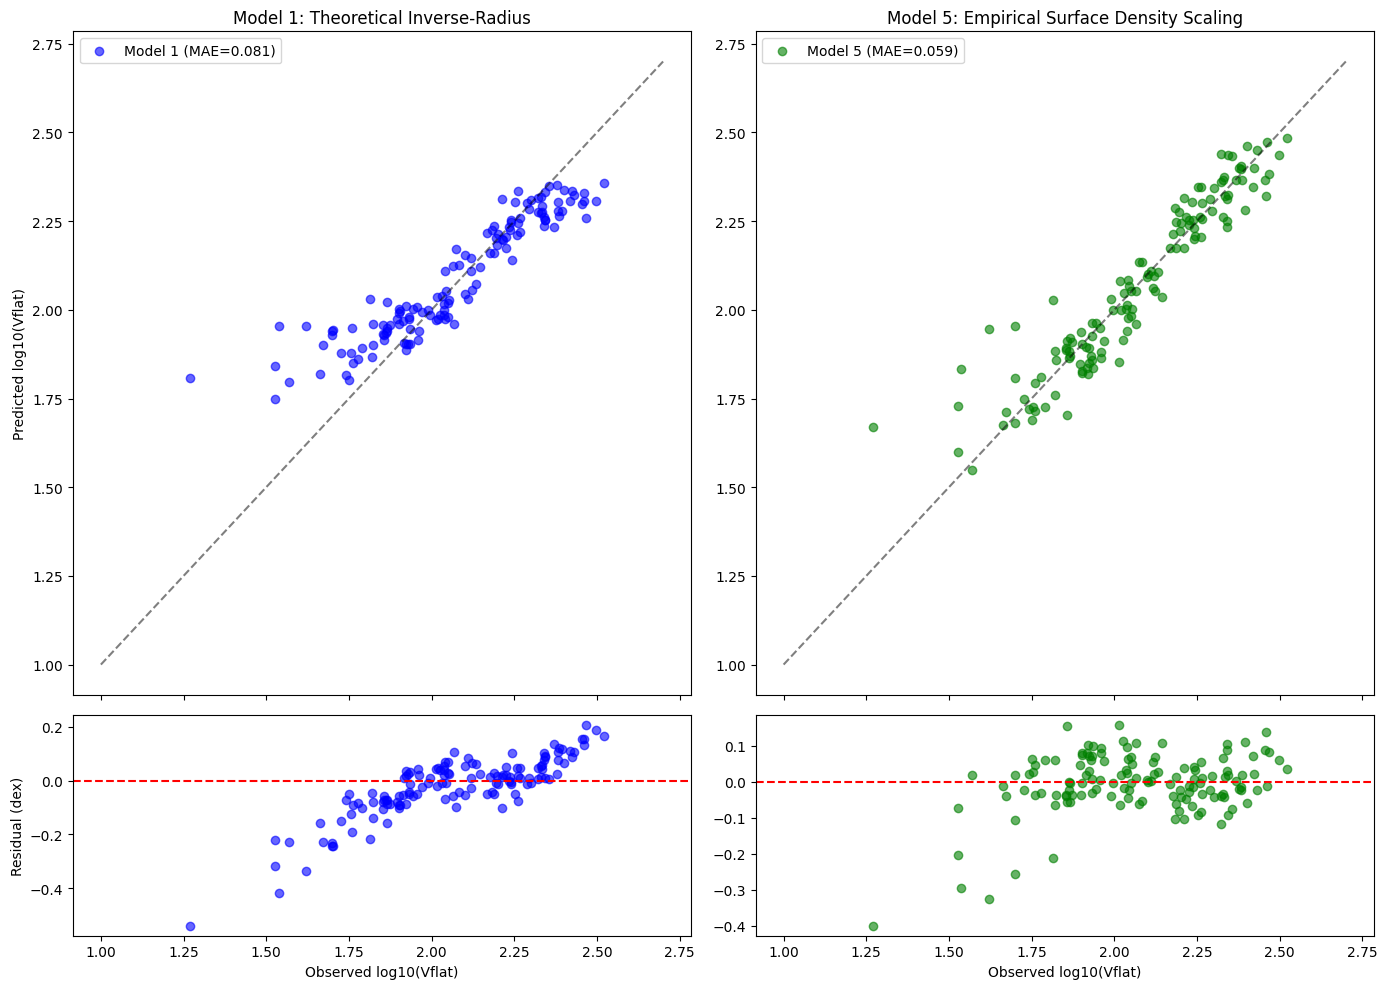

In [41]:
import matplotlib.pyplot as plt

# --- 2. Figure 1: Model 1 vs Model 5 Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex='col')

# Model 1 Predictions (Theoretical)
l_pred1 = log_Vpred(A1, Q1)
res1 = log_Vobs - l_pred1

# Model 5 Predictions (Empirical Sigma_b scaling)
l_pred5 = log_Vpred_M5(A5, Q5, gamma5)
res5 = log_Vobs - l_pred5

# Top Left: M1 Scatter
axes[0, 0].scatter(log_Vobs, l_pred1, alpha=0.6, color='blue', label=f'Model 1 (MAE={MAE1:.3f})')
axes[0, 0].plot([1, 2.7], [1, 2.7], 'k--', alpha=0.5)
axes[0, 0].set_title("Model 1: Theoretical Inverse-Radius")
axes[0, 0].set_ylabel("Predicted log10(Vflat)")
axes[0, 0].legend()

# Bottom Left: M1 Residuals
axes[1, 0].scatter(log_Vobs, res1, alpha=0.6, color='blue')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_ylabel("Residual (dex)")
axes[1, 0].set_xlabel("Observed log10(Vflat)")

# Top Right: M5 Scatter
axes[0, 1].scatter(log_Vobs, l_pred5, alpha=0.6, color='green', label=f'Model 5 (MAE={MAE5:.3f})')
axes[0, 1].plot([1, 2.7], [1, 2.7], 'k--', alpha=0.5)
axes[0, 1].set_title("Model 5: Empirical Surface Density Scaling")
axes[0, 1].legend()

# Bottom Right: M5 Residuals
axes[1, 1].scatter(log_Vobs, res5, alpha=0.6, color='green')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel("Observed log10(Vflat)")

plt.tight_layout()
plt.show()

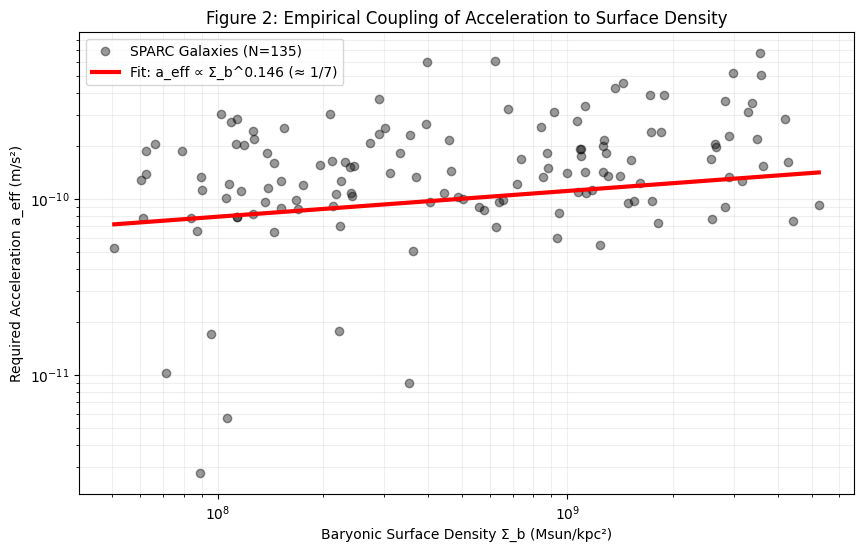

In [43]:
# --- 3. Figure 2: The 1/7 Scaling Law ---
plt.figure(figsize=(10, 6))

# Calculate required a_eff from data
a_req = (10**log_Vobs * 1e3)**4 / (G_SI * Mb_msun * MSUN_KG)

# Sort for smooth plotting of the fit
sort_idx = np.argsort(Sigma_b)
s_sorted = Sigma_b[sort_idx]

# Calculate Model 5 fit line
# a_eff = A * Q * mu_SI * sqrt(kappa_0)
# where mu = (Sigma_b/Sigma_ref)^gamma / KPC_M
mu_fit_SI = (s_sorted / Sigma_ref)**gamma5 / KPC_M
a_fit_SI = A5 * Q5 * mu_fit_SI * np.sqrt(kappa_0)

plt.loglog(Sigma_b, a_req, 'ok', alpha=0.4, label='SPARC Galaxies (N=135)')
plt.loglog(s_sorted, a_fit_SI, 'r-', linewidth=3, label=f'Fit: a_eff ∝ Σ_b^{gamma5:.3f} (≈ 1/7)')

plt.xlabel("Baryonic Surface Density Σ_b (Msun/kpc²)")
plt.ylabel("Required Acceleration a_eff (m/s²)")
plt.title("Figure 2: Empirical Coupling of Acceleration to Surface Density")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

### **Figure 1: Performance Comparison and Residual Analysis**
This figure compares the baseline theoretical model (Model 1) against the optimized empirical model (Model 5). The bottom panels show how Model 5 successfully removes the systematic tilting seen in the residuals of Model 1.

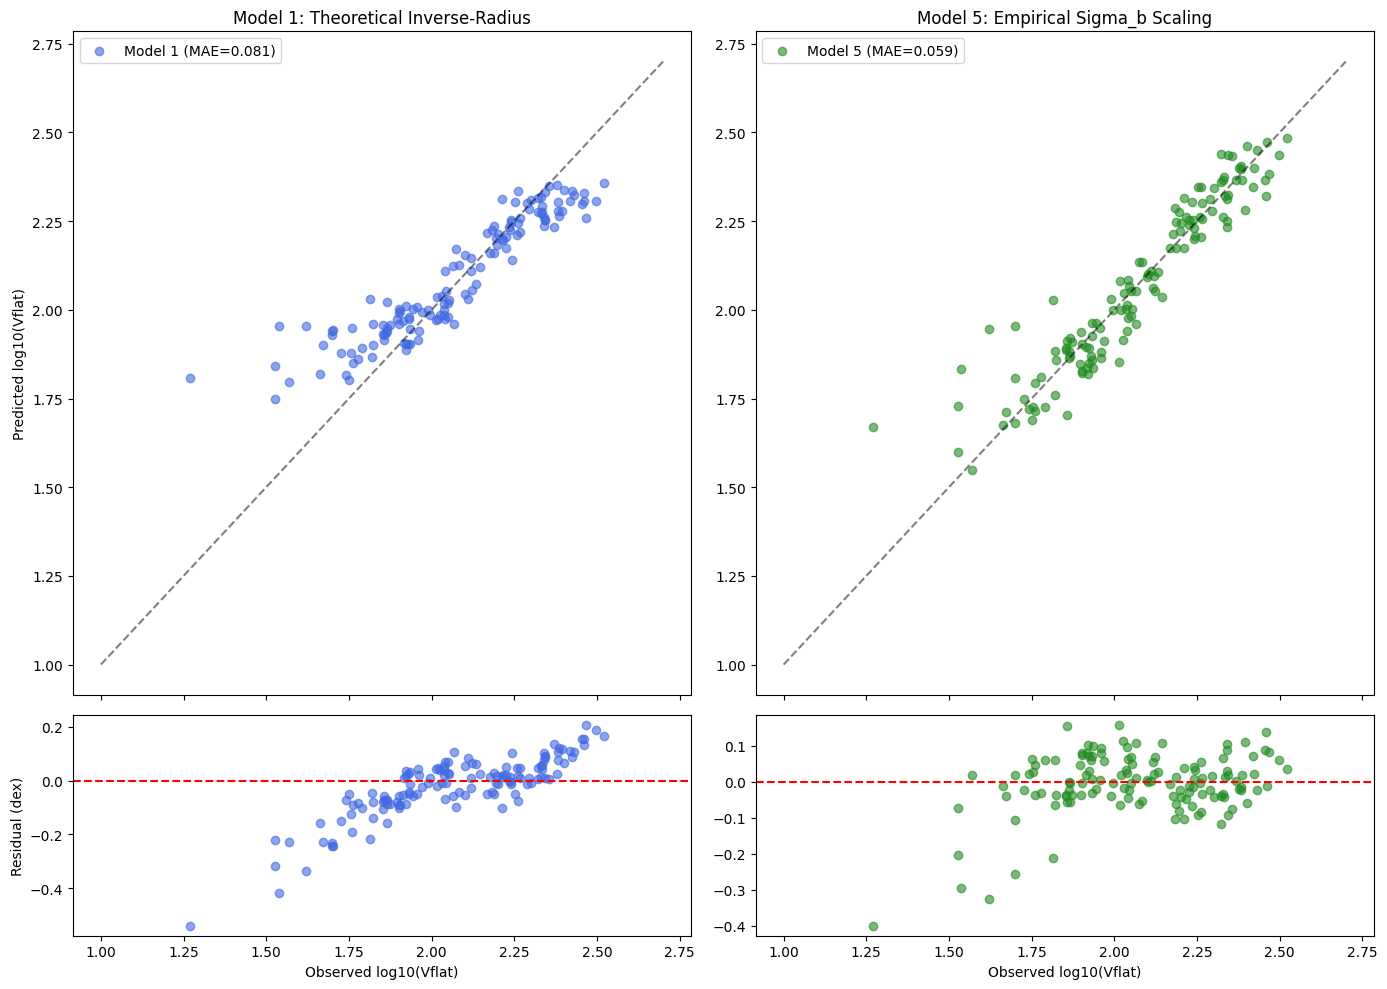

In [44]:
import matplotlib.pyplot as plt

# --- Figure 1 Generation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex='col')

# Predictions
l_pred1 = log_Vpred(A1, Q1)
res1 = log_Vobs - l_pred1
l_pred5 = log_Vpred_M5(A5, Q5, gamma5)
res5 = log_Vobs - l_pred5

# Model 1 Scatter
axes[0, 0].scatter(log_Vobs, l_pred1, alpha=0.6, color='royalblue', label=f'Model 1 (MAE={MAE1:.3f})')
axes[0, 0].plot([1, 2.7], [1, 2.7], 'k--', alpha=0.5)
axes[0, 0].set_title("Model 1: Theoretical Inverse-Radius")
axes[0, 0].set_ylabel("Predicted log10(Vflat)")
axes[0, 0].legend()

# Model 1 Residuals
axes[1, 0].scatter(log_Vobs, res1, alpha=0.6, color='royalblue')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_ylabel("Residual (dex)")
axes[1, 0].set_xlabel("Observed log10(Vflat)")

# Model 5 Scatter
axes[0, 1].scatter(log_Vobs, l_pred5, alpha=0.6, color='forestgreen', label=f'Model 5 (MAE={MAE5:.3f})')
axes[0, 1].plot([1, 2.7], [1, 2.7], 'k--', alpha=0.5)
axes[0, 1].set_title("Model 5: Empirical Sigma_b Scaling")
axes[0, 1].legend()

# Model 5 Residuals
axes[1, 1].scatter(log_Vobs, res5, alpha=0.6, color='forestgreen')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel("Observed log10(Vflat)")

plt.tight_layout()
plt.show()

### **Figure 2: The 1/7 Scaling Law**
This log-log plot demonstrates the primary discovery: the effective acceleration $a_{eff}$ is strongly coupled to the baryonic surface density $\Sigma_b$ via a power law with an exponent of $\approx 0.146$ (effectively $1/7$).

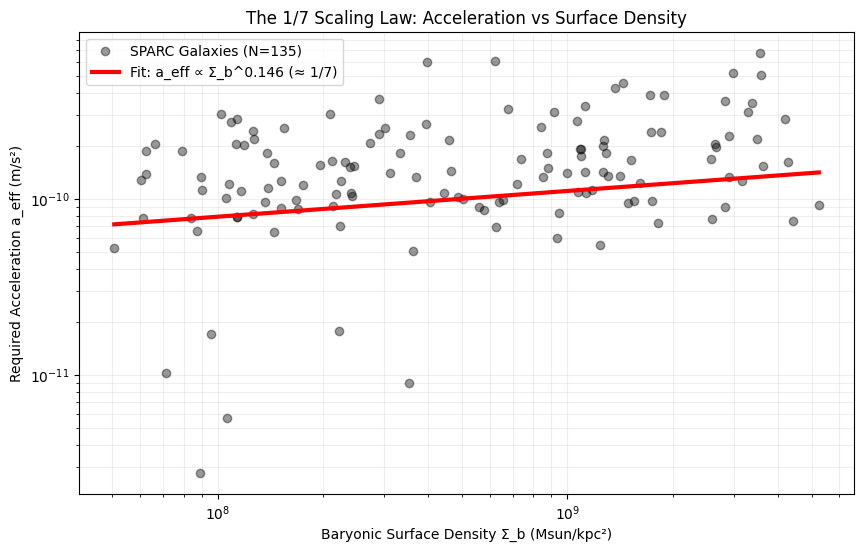

In [45]:
# --- Figure 2 Generation ---
plt.figure(figsize=(10, 6))

# Calculate demanded a_eff from data
a_req = (10**log_Vobs * 1e3)**4 / (G_SI * Mb_msun * MSUN_KG)

# Smooth line for the Model 5 fit
sort_idx = np.argsort(Sigma_b)
s_sorted = Sigma_b[sort_idx]
mu_fit_SI = (s_sorted / Sigma_ref)**gamma5 / KPC_M
a_fit_SI = A5 * Q5 * mu_fit_SI * np.sqrt(kappa_0)

plt.loglog(Sigma_b, a_req, 'ok', alpha=0.4, label='SPARC Galaxies (N=135)')
plt.loglog(s_sorted, a_fit_SI, 'r-', linewidth=3, label=f'Fit: a_eff ∝ Σ_b^{gamma5:.3f} (≈ 1/7)')

plt.xlabel("Baryonic Surface Density Σ_b (Msun/kpc²)")
plt.ylabel("Required Acceleration a_eff (m/s²)")
plt.title("The 1/7 Scaling Law: Acceleration vs Surface Density")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()